In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
import mlflow
import torch
from src.utils import helpers
from src.utils import visualization as vis
from src.utils.model_registry import MLFlowRegistry
from src.core.params import BaseParams
from src.core.exported_model import ExportedModel
from src.data.datamodule import CrowdDataModule
from src.utils import inspection

/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [ ]:
inspection.inspect_model('resnet101')

In [5]:
model = mlflow.pyfunc.load_model('models:/crowd_counting/43')

2026/06/14 20:24:12 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - matplotlib (current: 3.10.9, required: matplotlib==3.11.0)
 - numpy (current: 2.4.3, required: numpy==2.4.6)
 - Pillow (current: 12.1.1, required: Pillow==12.2.0)
 - scikit_learn (current: 1.8.0, required: scikit_learn==1.9.0)
 - timm (current: 1.0.26, required: timm==1.0.27)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.


In [4]:
model, params = MLFlowRegistry().load_model('crowd_counting', version='40', run_id='b10aab2456a441bc808482129d2e0cab')

/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/torch/export/pt2_archive/_package.py:790: UserWarning: The given buffer is not writable, and PyTorch does not support non-writable tensors. This means you can write to the underlying (supposedly non-writable) buffer using the tensor. You may want to copy the buffer to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:1586.)
  tensor = torch.frombuffer(


Model loaded from /teamspace/studios/this_studio/workspace/crowd_counting/trained_models/crowd_counting:40//data/model.pt2


In [15]:
params.padding_multiple = 352

In [53]:
(1 + (-1 + 352 // 4) // 8) * (1 + (-1 + 352 // 4) // 8)

121

In [2]:
from src.models.lit_model import BaseLitModel


lit_model = BaseLitModel.load_from_checkpoint('/teamspace/studios/this_studio/workspace/crowd_counting/trained_models/crowd_counting:40/run_20260610_224455/epoch=24-step=750.ckpt', weights_only=False)

In [ ]:
import numpy as np
dummy_input = np.random.randint(0, 256, size=(2, 704, 1056, 3), dtype=np.uint8)
model.predict(dummy_input)

[{'count': 310.67987060546875,
  'density_map': array([[[0.000979  , 0.00084378, 0.00078222, ..., 0.00084385,
           0.00080114, 0.00070846],
          [0.00101683, 0.00083537, 0.00077135, ..., 0.00079578,
           0.00075747, 0.00060994],
          [0.0009433 , 0.00078442, 0.00084015, ..., 0.00067543,
           0.0005905 , 0.00052593],
          ...,
          [0.00073722, 0.00078672, 0.0007495 , ..., 0.00044698,
           0.00064577, 0.0008057 ],
          [0.00070953, 0.00076396, 0.00073714, ..., 0.00054312,
           0.00065708, 0.00077005],
          [0.00072906, 0.00066739, 0.00064418, ..., 0.00065068,
           0.00068776, 0.00074844]]], shape=(1, 704, 1056), dtype=float32)},
 {'count': 316.045654296875,
  'density_map': array([[[0.00084093, 0.00077937, 0.0008324 , ..., 0.00073332,
           0.00069758, 0.00067014],
          [0.00092662, 0.00071349, 0.00079954, ..., 0.00066178,
           0.00066436, 0.00067704],
          [0.00097978, 0.00093216, 0.0008883 , ..., 0.

In [37]:
datamodule = CrowdDataModule(params=params)
datamodule.setup(stage='test')

182 images found in /teamspace/lightning_storage/datasets/ShanghaiTech/part_A/test_data/images
182 h5 files found in /teamspace/lightning_storage/datasets/ShanghaiTech/part_A/test_data/ground-truth-h5


In [14]:
model.evaluate(datamodule)

tensor([513.6063]) tensor([171.8294])
tensor([445.2180]) tensor([497.0636])
tensor([438.4309]) tensor([381.9256])
tensor([521.0331]) tensor([210.3973])
tensor([250.5358]) tensor([217.3769])
tensor([583.1710]) tensor([427.6055])
tensor([1283.3899]) tensor([1163.2383])
tensor([216.6062]) tensor([257.0872])
tensor([995.2886]) tensor([1225.8103])
tensor([260.9714]) tensor([288.4333])
tensor([212.1756]) tensor([175.6181])
tensor([368.1245]) tensor([373.5144])
tensor([976.2570]) tensor([1063.9664])
tensor([846.4764]) tensor([1016.6429])
tensor([576.8351]) tensor([448.3900])
tensor([410.2893]) tensor([254.8806])
tensor([686.0919]) tensor([65.9953])
tensor([307.2401]) tensor([140.8374])
tensor([1538.3644]) tensor([1183.6310])
tensor([405.6709]) tensor([284.3199])
tensor([1556.5217]) tensor([1588.7800])
tensor([285.5366]) tensor([237.5375])
tensor([280.8386]) tensor([244.3082])
tensor([212.5282]) tensor([319.3656])
tensor([164.2898]) tensor([130.5617])
tensor([1383.4607]) tensor([1204.2678])
te

{'MAE': 80.48564910888672,
 'NAE': 0.26107412576675415,
 'RMSE': 125.09720611572266}

In [38]:
sample, target, count = helpers.get_sample_from_dm(datamodule, index=6)
sample.shape

torch.Size([1, 3, 704, 1024])

In [8]:
from torchvision.transforms import v2
from PIL import Image
original_image = Image.open('/teamspace/studios/this_studio/workspace/crowd_counting/testing_images/input/hama_protests.jpg').convert('RGB')
image = helpers.transform_sample(original_image, params)

In [9]:
result  = lit_model.predict(image)
result

(4300.138671875,
 tensor([[[0.0006, 0.0005, 0.0003,  ..., 0.0003, 0.0004, 0.0004],
          [0.0005, 0.0003, 0.0002,  ..., 0.0002, 0.0003, 0.0004],
          [0.0004, 0.0002, 0.0002,  ..., 0.0002, 0.0002, 0.0003],
          ...,
          [0.0005, 0.0004, 0.0003,  ..., 0.0004, 0.0005, 0.0006],
          [0.0006, 0.0005, 0.0003,  ..., 0.0004, 0.0005, 0.0005],
          [0.0006, 0.0006, 0.0004,  ..., 0.0005, 0.0005, 0.0006]]]))

In [ ]:
vis.visualize_sample(original_image, pred=result)

In [18]:
from src.models.model import CrowdCounter


crowd_model = CrowdCounter(params=params)
crowd_model.eval()
crowd_model.load_state_dict(model.model.state_dict())

RuntimeError: Error(s) in loading state_dict for CrowdCounter:
	Missing key(s) in state_dict: "net.net.encoder._conv_stem.weight", "net.net.encoder._bn0.weight", "net.net.encoder._bn0.bias", "net.net.encoder._bn0.running_mean", "net.net.encoder._bn0.running_var", "net.net.encoder._blocks.0._depthwise_conv.weight", "net.net.encoder._blocks.0._bn1.weight", "net.net.encoder._blocks.0._bn1.bias", "net.net.encoder._blocks.0._bn1.running_mean", "net.net.encoder._blocks.0._bn1.running_var", "net.net.encoder._blocks.0._se_reduce.weight", "net.net.encoder._blocks.0._se_reduce.bias", "net.net.encoder._blocks.0._se_expand.weight", "net.net.encoder._blocks.0._se_expand.bias", "net.net.encoder._blocks.0._project_conv.weight", "net.net.encoder._blocks.0._bn2.weight", "net.net.encoder._blocks.0._bn2.bias", "net.net.encoder._blocks.0._bn2.running_mean", "net.net.encoder._blocks.0._bn2.running_var", "net.net.encoder._blocks.1._depthwise_conv.weight", "net.net.encoder._blocks.1._bn1.weight", "net.net.en

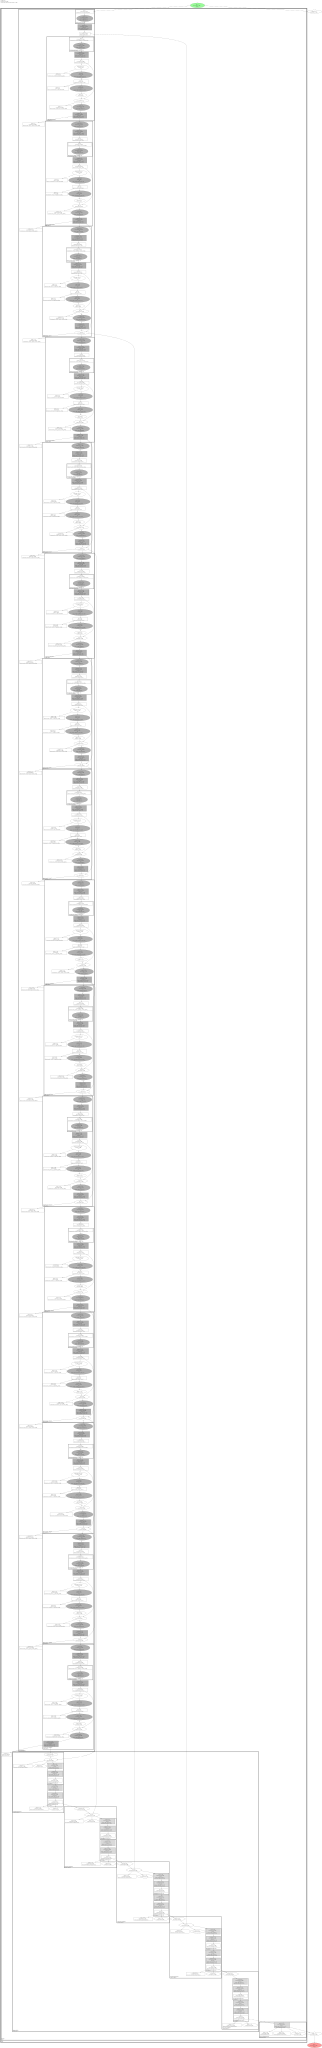

[Errno 2] No such file or directory: 'xdg-open'


In [11]:
vis.visualize_model_graph(crowd_model, sample=sample)